## <span style="color:blue; font-size:22px;">2. Data Preprocessing</span>

In [22]:
df_clean = df.copy()

In [23]:
df_clean.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [24]:
print(df_clean.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [25]:
df_clean.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [1]:
# Categorical Vs Numerical

In [26]:
categorical_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Geography', 'Gender'], dtype='str')
Numerical Columns: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')


In [2]:
# Oulier Checking

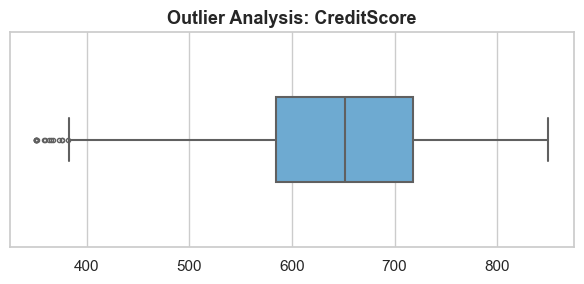

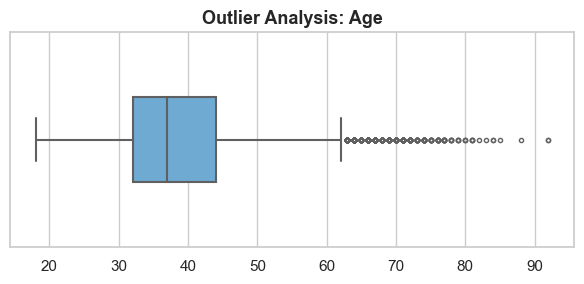

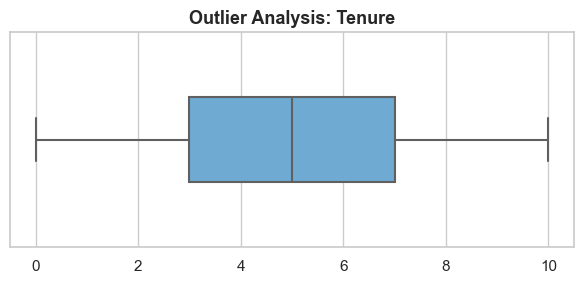

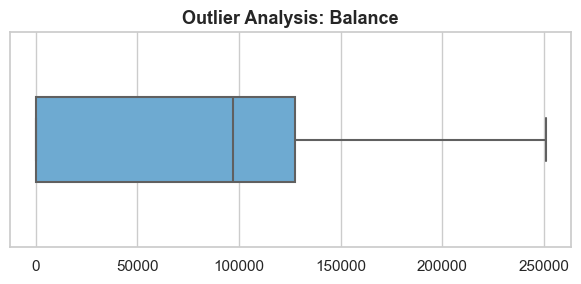

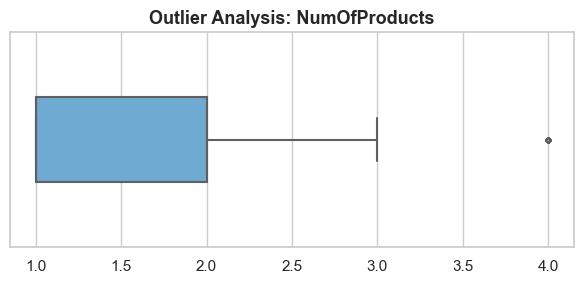

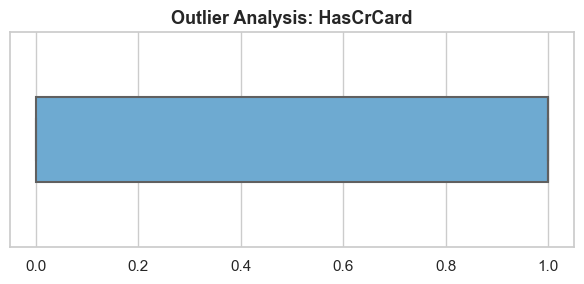

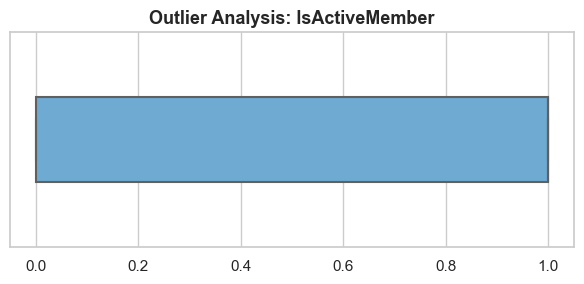

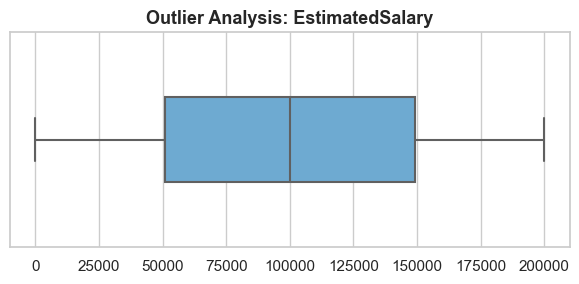

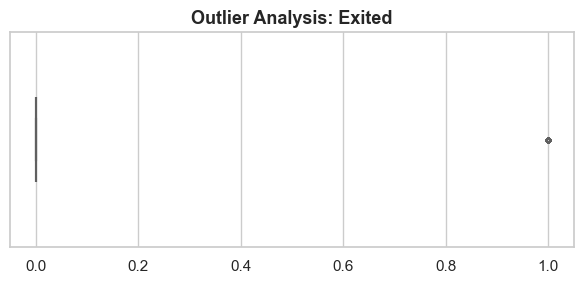

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col in numerical_cols:
    plt.figure(figsize=(6, 3))  # smaller, cleaner size
    
    sns.boxplot(
        x=df_clean[col],
        color="#5DADE2",   # professional blue
        width=0.4,
        linewidth=1.5,
        fliersize=3
    )
    
    plt.title(f"Outlier Analysis: {col}", fontsize=13, fontweight='bold')
    plt.xlabel("")
    
    plt.tight_layout()
    plt.show()

In [3]:
# IQR Method (Actual Detection)

In [29]:
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers
Exited: 2037 outliers


In [4]:
# Outliers appears in some of the column and this all are real bank customers data. So we do not remove this.

In [5]:
# One-Hot Encoding

In [30]:
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

In [ ]:
# Label Encoding

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

In [32]:
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

In [6]:
# Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)


In [35]:
print("Sample X_train:\n", X_train[:5])
print("Sample y_train:\n", y_train[:5])

Sample X_train:
       CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
9254          686       1   32       6       0.00              2          1   
1561          632       1   42       4  119624.60              2          1   
1670          559       1   24       3  114739.92              1          1   
6087          561       0   27       9  135637.00              1          1   
6669          517       1   56       9  142147.32              1          0   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
9254               1        179093.26              False            False  
1561               1        195978.86               True            False  
1670               0         85891.02              False             True  
6087               0        153080.40              False            False  
6669               0         39488.04              False            False  
Sample y_train:
 9254    0
1561    0
1670    1
6087 